In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.layers import Dense,MaxPooling2D,Conv2D,Flatten,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import cv2

In [46]:
dataset = tf.keras.preprocessing.image_dataset_from_directory('/content/drive/MyDrive/archive (2)/data',
                                                              shuffle = True,
                                                              image_size = (64,64),
                                                              batch_size = 32)

Found 3347 files belonging to 2 classes.


In [47]:
classes = ['benign','malignant']
classes

['benign', 'malignant']

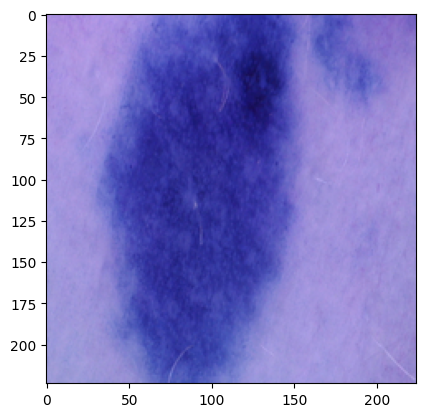

In [48]:
plt.imshow(cv2.imread('/content/drive/MyDrive/archive (2)/data/test/benign/1003.jpg'))

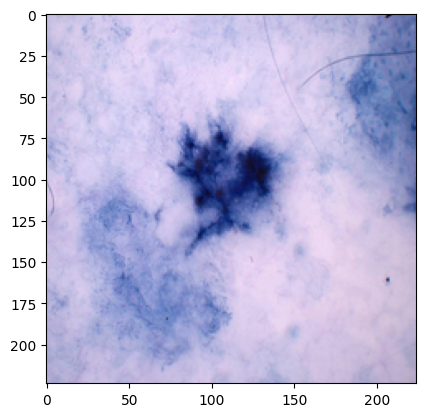

In [49]:
plt.imshow(cv2.imread('/content/drive/MyDrive/archive (2)/data/test/malignant/1003.jpg'))

In [50]:
datagen = ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,
                             horizontal_flip=True,
                             validation_split = 0.2)

training_set = datagen.flow_from_directory('/content/drive/MyDrive/archive (2)/data/train',
                                           target_size=(64,64),
                                           batch_size=32,
                                           class_mode='binary',
                                           subset = 'training')

Found 2142 images belonging to 2 classes.


In [51]:
validation_set = datagen.flow_from_directory('/content/drive/MyDrive/archive (2)/data/test',
                                           target_size=(64,64),
                                           batch_size=32,
                                           class_mode='binary',
                                           subset = 'validation')

Found 134 images belonging to 2 classes.


In [52]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',padding = 'same',input_shape=(64,64,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu',padding = 'same'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Conv2D(96,(3,3),activation='relu',padding = 'same'))
model.add(Conv2D(128,(3,3),activation='relu',padding = 'same'))
model.add(Conv2D(160,(3,3),activation='relu',padding = 'same'))
model.add(Conv2D(192,(3,3),activation='relu',padding = 'same'))
model.add(Conv2D(224,(3,3),activation='relu',padding = 'same'))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))

In [53]:
model.compile(loss = 'binary_crossentropy',
              optimizer = Adam(learning_rate = 0.001),
              metrics = ['accuracy'])

In [54]:
training_data = model.fit(x = training_set,epochs=15,validation_data=validation_set)
training_data

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.5523 - loss: 0.7013 - val_accuracy: 0.7313 - val_loss: 0.6836
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7395 - loss: 0.5290 - val_accuracy: 0.7761 - val_loss: 0.4926
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.7865 - loss: 0.4308 - val_accuracy: 0.7612 - val_loss: 0.5041
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7839 - loss: 0.4001 - val_accuracy: 0.7164 - val_loss: 0.5521
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.7772 - loss: 0.4483 - val_accuracy: 0.7537 - val_loss: 0.5194
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8116 - loss: 0.3859 - val_accuracy: 0.6269 - val_loss: 0.5996
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.8090 - loss: 0.4264 - val_accuracy: 0.7761 - val_loss: 0.4929
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.7747 - loss: 0.4465 - val_accuracy: 0.6119 - v

In [55]:
hist = training_data.history
hist.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [56]:
hist['val_accuracy'][-1]

0.7761194109916687

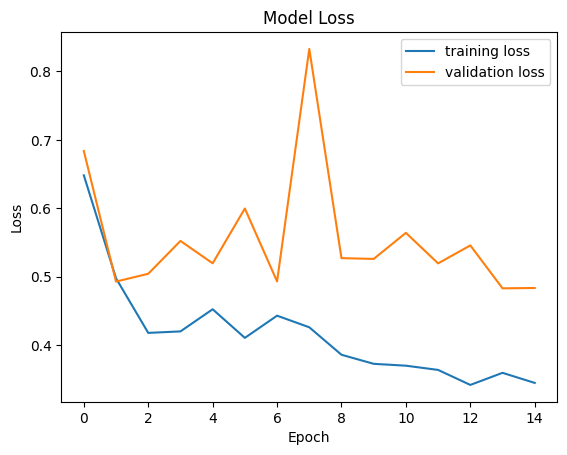

In [57]:
plt.plot(hist['loss'], label = 'training loss')
plt.plot(hist['val_loss'], label = 'validation loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

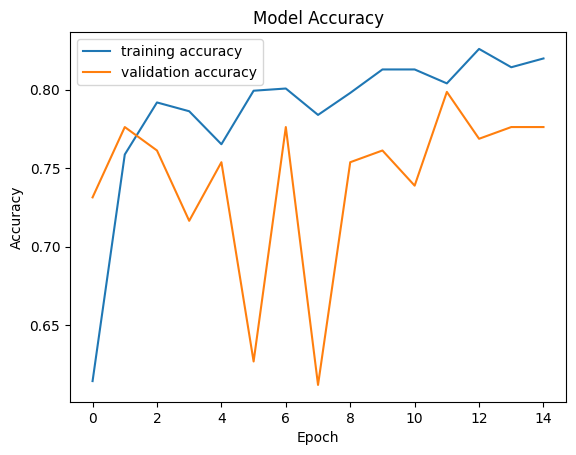

In [58]:
plt.plot(hist['accuracy'], label = 'training accuracy')
plt.plot(hist['val_accuracy'], label = 'validation accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

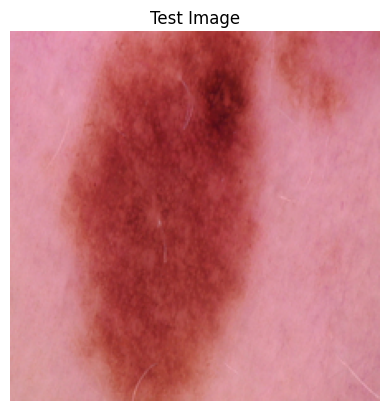

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
predicted_class: benign


In [59]:
image_path = '/content/drive/MyDrive/archive (2)/data/test/benign/1003.jpg'
test_image = load_img(image_path,target_size=(64,64))


img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Test Image')
plt.show()

test_image_array = img_to_array(test_image)
test_image_array = np.expand_dims(test_image_array,axis=0)
preproccesed_image = test_image_array / 255.0


result = model.predict(preproccesed_image)
predicted_class_index = 1 if result [0][0] > 0.5 else 0
predicted_class_name = classes[predicted_class_index]


print('predicted_class:',predicted_class_name)

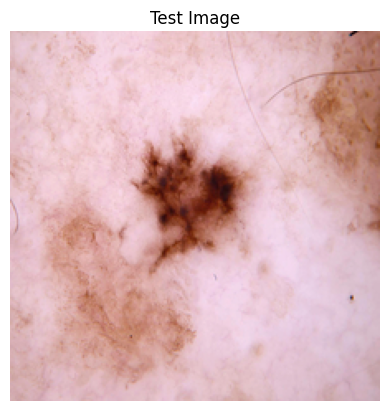

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
predicted_class: malignant


In [60]:
image_path = '/content/drive/MyDrive/archive (2)/data/test/malignant/1003.jpg'
test_image = load_img(image_path,target_size=(64,64))


img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Test Image')
plt.show()

test_image_array = img_to_array(test_image)
test_image_array = np.expand_dims(test_image_array,axis=0)
preproccesed_image = test_image_array / 255.0


result = model.predict(preproccesed_image)
predicted_class_index = 1 if result [0][0] > 0.5 else 0
predicted_class_name = classes[predicted_class_index]


print('predicted_class:',predicted_class_name)

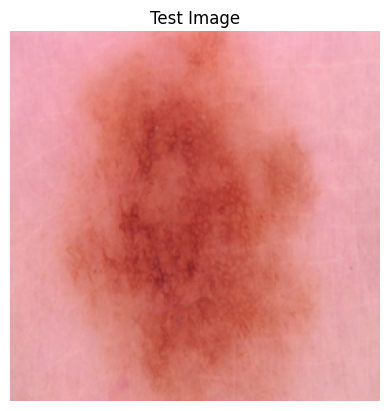

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
predicted_class: benign


In [61]:
image_path = '/content/drive/MyDrive/archive (2)/data/test/benign/1143.jpg'
test_image = load_img(image_path,target_size=(64,64))


img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Test Image')
plt.show()

test_image_array = img_to_array(test_image)
test_image_array = np.expand_dims(test_image_array,axis=0)
preproccesed_image = test_image_array / 255.0


result = model.predict(preproccesed_image)
predicted_class_index = 1 if result [0][0] > 0.5 else 0
predicted_class_name = classes[predicted_class_index]


print('predicted_class:',predicted_class_name)